## WORKBOOK TO PLOT THE RASTERS using python

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import spikeinterface.full as si
import sys
import os

# MEAPlotter theme — applied globally for this session
_RC = {
    "font.family":           "sans-serif",
    "font.sans-serif":       ["Liberation Sans", "Arial", "DejaVu Sans", "sans-serif"],
    "svg.fonttype":          "none",
    "pdf.fonttype":          42,
    "axes.titlesize":        9,
    "axes.titleweight":      "bold",
    "axes.labelsize":        8,
    "axes.labelweight":      "bold",
    "font.weight":           "bold",
    "xtick.labelsize":       6,
    "ytick.labelsize":       6,
    "legend.fontsize":       7,
    "legend.title_fontsize": 8,
    "xtick.major.size":      3,
    "ytick.major.size":      3,
    "xtick.major.width":     0.8,
    "ytick.major.width":     0.8,
}
plt.rcParams.update(_RC)

In [2]:
file_path = '/Volumes/MEA_Backup/raw_data/rbs_maxtwo_desktop/harddisk20tb/CDKL5-E6D_T1_C1_05152024/CDKL5-E6D_T1_C1_05152024/240607/M07427/Network/000086/data.raw.h5'

recording1 = si.read_maxwell(file_path,stream_id='well000')

#recording = si.ConcatenateSegmentRecording([recording1,recording2])
channel_ids = recording1.get_channel_ids()
fs = recording1.get_sampling_frequency()
num_chan = recording1.get_num_channels()
num_seg = recording1.get_num_segments()
total_recording = recording1.get_total_duration()

#end_time = int((total_recording-1))
start_time = 0
end_time = 300

#print('Channel ids:', channel_ids)
print('Sampling frequency:', fs)
print('Number of channels:', num_chan)
print('Number of segments:', num_seg)
print(f"total_recording: {total_recording} s")
recording1 = si.unsigned_to_signed(recording1)
recording_bp = si.bandpass_filter(recording1, freq_min=300, freq_max=3000)
recording_lfp = si.bandpass_filter(recording1, freq_min=1, freq_max=300,ignore_low_freq_error=True)

recodring_cmr = si.common_reference(recording_bp, reference='global', operator='median')
#recording_chunk = recodring_cmr.frame_slice(start_frame= 1*fs,end_frame=425*fs)
recording_chunk = recodring_cmr.frame_slice(start_frame= start_time*fs,end_frame=end_time*fs)
#recording_chunk =si.scale(recording_chunk, gain=3.0)
print(f"chunk duration: {recording_chunk.get_total_duration()} s")

The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
Sampling frequency: 10000.0
Number of channels: 1019
Number of segments: 1
total_recording: 300.03999999999996 s
chunk duration: 300.0 s


/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/spikeinterface/preprocessing/filter.py:122: UserWarning: The margin size (50000 samples) is more than 20% of the global chunk size 10000 samples. This may lead to performance bottlenecks when chunking. Consider increasing the chunk_size or chunk_duration to minimize margin overhead.
  warnings.warn(


In [3]:
binary_file_path = '/Volumes/MEA_Backup/raw_data/rbs_maxtwo_desktop/harddisk20tb/CDKL5-E6D_T1_C1_05152024/CDKL5-E6D_T1_C1_05152024/240607/M07427/Network/000086/binary.raw'

In [4]:

job_kwargs = dict(n_jobs=32, chunk_duration="1s", progress_bar=True)
si.write_binary_recording(recording_chunk, binary_file_path, dtype=recording_chunk.get_dtype(), **job_kwargs)

The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!
The h5 compression library for Maxwell is already located in /Users/mandarmp/hdf5_plugin_path_maxwell/libcompression.dylib!


write_binary_recording (workers: 8 processes spawn):   0%|          | 0/300 [00:00<?, ?it/s]

In [5]:
rec_bin = si.read_binary(
    binary_file_path,
    sampling_frequency=recording_chunk.get_sampling_frequency(),
    dtype=recording_chunk.get_dtype(),
    num_channels=recording_chunk.get_num_channels(),
    channel_ids=recording_chunk.get_channel_ids(),
)

In [6]:
from spikeinterface.sortingcomponents.peak_detection import detect_peaks
import numpy as np

peaks = detect_peaks(
    rec_bin,
    method='by_channel',
    detect_threshold=5,       # 5× MAD noise estimate (standard)
    peak_sign='neg',          # extracellular spikes are negative
    exclude_sweep_ms=0.1,     # prevents double-counting same spike
    n_jobs=8,
    chunk_duration='10s',     # larger chunks avoids the margin warning
    progress_bar=True,
)

fs = rec_bin.get_sampling_frequency()
peak_counts = {
    ch_idx: {'spike_indices': peaks['sample_index'][peaks['channel_index'] == ch_idx].tolist()}
    for ch_idx in range(rec_bin.get_num_channels())
}
print(f"Total spikes: {len(peaks)}  |  fs: {fs} Hz")

/Users/mandarmp/anaconda3/envs/mea/lib/python3.11/site-packages/spikeinterface/sortingcomponents/peak_detection/main.py:60: UserWarning: The signature of detect_peaks() has changed, now method_kwargs and job_kwargs are dinstinct params.This warning will raise an error in version 0.105.0
  warnings.warn(


noise_level (workers: 8 processes spawn):   0%|          | 0/20 [00:00<?, ?it/s]

detect peaks (by_channel) (workers: 8 processes spawn):   0%|          | 0/30 [00:00<?, ?it/s]

Total spikes: 2730530  |  fs: 10000.0 Hz


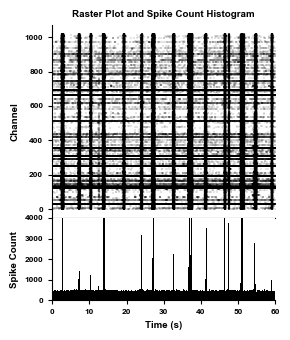

In [7]:
import matplotlib.pyplot as plt
import numpy as np

sampling_rate = 10000
start_time = 0
end_time = 60
bin_width = 0.1
color = 'black'
stim_start = 905.17
stim_period = 0.502
stim_times = np.arange(stim_start, end_time + stim_period, stim_period)

start_index = int(start_time * sampling_rate)
end_index   = int(end_time   * sampling_rate)

with plt.rc_context(_RC):
    fig = plt.figure(figsize=(3.0,3.5))
    gs = fig.add_gridspec(2, 1, height_ratios=[7, 3], hspace=0)
    ax_raster = fig.add_subplot(gs[0])
    ax_hist   = fig.add_subplot(gs[1], sharex=ax_raster)

    for channel_idx, channel_data in peak_counts.items():
        filtered = [i for i in channel_data['spike_indices'] if start_index <= i < end_index]
        spike_times = [i / sampling_rate for i in filtered]
        ax_raster.scatter(spike_times, [channel_idx] * len(spike_times),
                          s=1, color=color, alpha=0.1, marker='|', rasterized=True)

    for stim_time in stim_times:
        ax_raster.axvline(stim_time, color='red', linewidth=0.8, alpha=0.7)
        ax_hist.axvline(stim_time, color='red', linewidth=0.8, alpha=0.7)

    ax_raster.set_title("Raster Plot and Spike Count Histogram")
    ax_raster.set_ylabel("Channel")
    ax_raster.set_xlim(start_time, end_time)
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    sns.despine(ax=ax_raster)

    all_spike_times = []
    for channel_data in peak_counts.values():
        filtered = [i for i in channel_data['spike_indices'] if start_index <= i < end_index]
        all_spike_times.extend([i / sampling_rate for i in filtered])

    bins = np.arange(start_time, end_time + bin_width, bin_width)
    ax_hist.hist(all_spike_times, bins=bins, color=color, alpha=1.0)
    ax_raster.set_title("Raster Plot and Spike Count Histogram", fontsize=7, fontweight='bold')
    ax_raster.set_ylabel("Channel", fontsize=7, fontweight='bold')
    ax_raster.tick_params(axis='y', labelsize=6)

    ax_hist.set_xlabel("Time (s)", fontsize=7, fontweight='bold')
    ax_hist.set_ylabel("Spike Count", fontsize=7, fontweight='bold')
    ax_hist.tick_params(axis='both', labelsize=6)
    ax_hist.set_ylim(0, 4000)
    sns.despine(ax=ax_hist)

    plt.tight_layout()
    plt.savefig('/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig1/raster_histogram_DIV23.svg', dpi=300)
    plt.show()

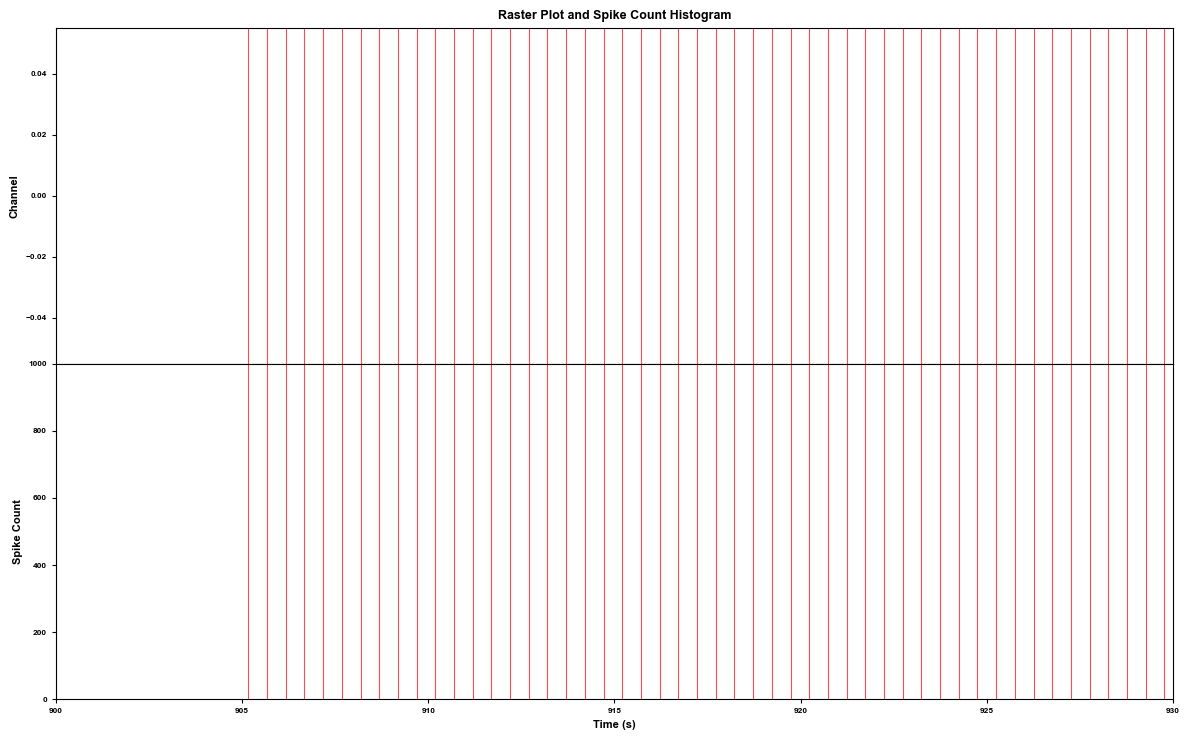

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Sampling rate (in Hz) of the recording
sampling_rate = 10000  # Replace with the actual sampling rate of your data
start_time = 900  # Start time in seconds
end_time = 930  # End time in seconds
bin_width = 0.03  # seconds
color = 'royalblue'
stim_start = 905.17
stim_period = 0.502
stim_times = np.arange(stim_start, end_time + stim_period, stim_period)

# Define the time window for the raster plot
window_duration = end_time - start_time
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

# Initialize a figure with two subplots (raster plot and histogram)
fig = plt.figure(figsize=(12, 7.5))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0)  # No gap between plots

# Create axes once (prevents duplicate y-axis labels)
ax_raster = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharex=ax_raster)

# Raster plot (top)
for channel_idx, channel_data in peak_counts.items():
    filtered_spike_indices = [index for index in channel_data['spike_indices'] if start_index <= index < end_index]
    spike_times = [index / sampling_rate for index in filtered_spike_indices]
    ax_raster.scatter(
        spike_times,
        [channel_idx] * len(spike_times),
        s=1,
        color=color,
        alpha=1.0,
        marker='|',
        rasterized=True,
    )

# Stimulus markers
for stim_time in stim_times:
    ax_raster.axvline(stim_time, color='red', linewidth=0.8, alpha=0.7)
    ax_hist.axvline(stim_time, color='red', linewidth=0.8, alpha=0.7)

# Customize the raster plot
ax_raster.set_title("Raster Plot and Spike Count Histogram")
ax_raster.set_ylabel("Channel")
ax_raster.set_xlim(start_time, end_time)
ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

# Combine all spike times across channels for the histogram
all_spike_times = []
for channel_data in peak_counts.values():
    filtered_spike_indices = [index for index in channel_data['spike_indices'] if start_index <= index < end_index]
    all_spike_times.extend([index / sampling_rate for index in filtered_spike_indices])

# Create a histogram of spike counts over time
bins = np.arange(start_time, end_time + bin_width, bin_width)
ax_hist.hist(all_spike_times, bins=bins, color=color, alpha=1.0)

# Customize the histogram
ax_hist.set_xlabel("Time (s)")
ax_hist.set_ylabel("Spike Count")
ax_hist.set_xlim(start_time, end_time)
ax_hist.set_ylim(0, 1000)  # Add some padding to the y-axis

# Show the combined figure
plt.tight_layout()
#plt.savefig('/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig1/raster_histogram_DIV5.svg', dpi=300)
plt.show()

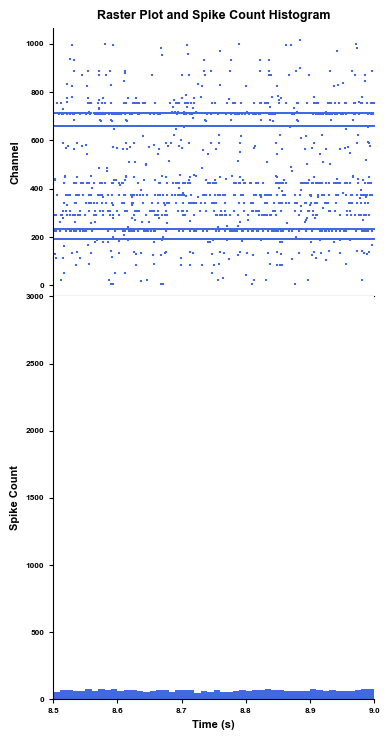

In [13]:
import matplotlib.pyplot as plt
import numpy as np

sampling_rate = 10000
start_time = 8.5
end_time = 9
bin_width = 0.01
color = 'royalblue'

start_index = int(start_time * sampling_rate)
end_index   = int(end_time   * sampling_rate)

with plt.rc_context(_RC):
    fig = plt.figure(figsize=(4, 7.5))
    gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.5], hspace=0)
    ax_raster = fig.add_subplot(gs[0])
    ax_hist   = fig.add_subplot(gs[1], sharex=ax_raster)

    for channel_idx, channel_data in peak_counts.items():
        filtered = [i for i in channel_data['spike_indices'] if start_index <= i < end_index]
        spike_times = [i / sampling_rate for i in filtered]
        ax_raster.scatter(spike_times, [channel_idx] * len(spike_times),
                          s=1, color=color, marker='|', rasterized=True)

    ax_raster.set_title("Raster Plot and Spike Count Histogram")
    ax_raster.set_ylabel("Channel")
    ax_raster.set_xlim(start_time, end_time)
    ax_raster.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    sns.despine(ax=ax_raster)

    all_spike_times = []
    for channel_data in peak_counts.values():
        filtered = [i for i in channel_data['spike_indices'] if start_index <= i < end_index]
        all_spike_times.extend([i / sampling_rate for i in filtered])

    bins = np.arange(start_time, end_time + bin_width, bin_width)
    ax_hist.hist(all_spike_times, bins=bins, color=color, alpha=1.0)
    ax_hist.set_xlabel("Time (s)")
    ax_hist.set_ylabel("Spike Count")
    ax_hist.set_xlim(start_time, end_time)
    ax_hist.set_ylim(0, 3000)
    sns.despine(ax=ax_hist)

    plt.tight_layout()
    #plt.savefig('/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig1/raster_histogram_DIV5.svg', dpi=300)
    plt.show()

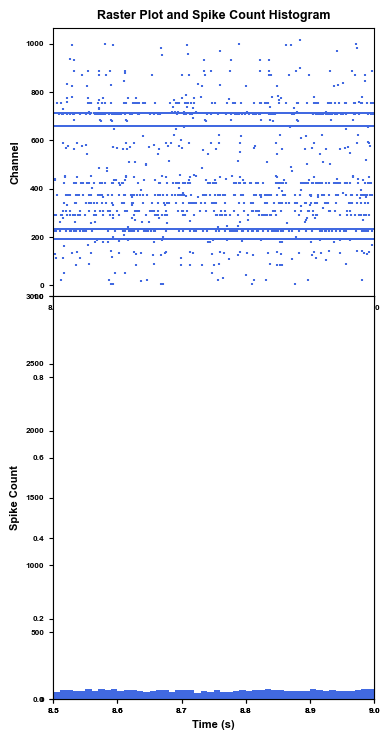

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# Sampling rate (in Hz) of the recording
sampling_rate = 10000  # Replace with the actual sampling rate of your data
start_time = 8.5# Start time in seconds
end_time = 9 # End time in seconds
bin_width = 0.01  # seconds
color = 'royalblue'
# Define the time window for the raster plot
window_duration = end_time - start_time
start_index = int(start_time * sampling_rate)
end_index = int(end_time * sampling_rate)

# Initialize a figure with two subplots (raster plot and histogram)
fig = plt.figure(figsize=(4, 7.5))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.5], hspace=0)  # No gap between plots

# Histogram (bottom)
ax_hist = fig.add_subplot(gs[1])  # Create the histogram axis first

# Raster plot (top)
ax_raster = fig.add_subplot(gs[0], sharex=ax_hist)  # Share x-axis with the histogram
for channel_idx, channel_data in peak_counts.items():
    # Keep only spikes in the 5-10 s window
    filtered_spike_indices = [index for index in channel_data['spike_indices'] if start_index <= index < end_index]

    # Convert spike indices to absolute time in seconds
    spike_times = [index / sampling_rate for index in filtered_spike_indices]

    # Plot the spikes as dots in the raster plot
    ax_raster.scatter(spike_times, [channel_idx] * len(spike_times), s=1, color=color, marker='|', rasterized=True)

# Customize the raster plot
ax_raster.set_title("Raster Plot and Spike Count Histogram")
ax_raster.set_ylabel("Channel")
ax_raster.set_xlabel("Time (s)")
ax_raster.set_xlim(start_time, end_time)
ax_raster.tick_params(axis='x', which='both', bottom=True, labelbottom=True)

# Histogram (bottom)
ax_hist = fig.add_subplot(gs[1], sharex=ax_raster)  # Share x-axis with the raster plot

# Combine all spike times across channels for the histogram
all_spike_times = []
for channel_data in peak_counts.values():
    filtered_spike_indices = [index for index in channel_data['spike_indices'] if start_index <= index < end_index]
    all_spike_times.extend([index / sampling_rate for index in filtered_spike_indices])

# Create a histogram of spike counts over time
bins = np.arange(start_time, end_time + bin_width, bin_width)
ax_hist.hist(all_spike_times, bins=bins, color=color, alpha=1.0)

# Customize the histogram
ax_hist.set_xlabel("Time (s)")
ax_hist.set_ylabel("Spike Count")
ax_hist.set_xlim(start_time, end_time)
ax_hist.set_ylim(0, 3000)  # Add some padding to the y-axis

# Show the combined figure
plt.tight_layout()
#plt.savefig('/Users/mandarmp/Documents/PHD/HD_MEA_PAPERWITHCDKL5/Fig1/raster_histogram_DIV5.svg', dpi=300)
plt.show()

import matplotlib.pyplot as plt
import numpy as np

sampling_rate = 10000
time_window = 60
max_index = int(time_window * sampling_rate)

with plt.rc_context(_RC):
    fig = plt.figure(figsize=(2.8, 4.5))
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
    ax_raster = fig.add_subplot(gs[0])
    ax_hist   = fig.add_subplot(gs[1], sharex=ax_raster)

    all_spike_times = []
    for ch, data in peak_counts.items():
        spikes = np.array(data['spike_indices'])
        spikes = spikes[spikes < max_index]
        if spikes.size == 0:
            continue
        spike_times = spikes / sampling_rate
        all_spike_times.append(spike_times)
        ax_raster.scatter(spike_times, np.full_like(spike_times, ch),
                          s=1.0, color='black', marker='|', linewidths=0.3, rasterized=True)

    ax_raster.set_title("Spontaneous Network Activity")
    ax_raster.set_ylabel("Channel")
    ax_raster.set_xlim(0, time_window)
    ax_raster.set_ylim(0, len(peak_counts))
    ax_raster.tick_params(axis='x', labelbottom=False)
    sns.despine(ax=ax_raster)

    all_spike_times = np.concatenate(all_spike_times) if all_spike_times else np.array([])
    bin_width = 0.2
    bins = np.arange(0, time_window + bin_width, bin_width)
    counts, _ = np.histogram(all_spike_times, bins=bins)
    rate = counts / (bin_width * len(peak_counts))

    ax_hist.bar(bins[:-1], rate, width=bin_width, color='black', align='edge')
    ax_hist.set_xlabel("Time (s)")
    ax_hist.set_ylabel("Hz")
    sns.despine(ax=ax_hist)

    plt.tight_layout(pad=0.3)
    plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sampling_rate = rec_bin.get_sampling_frequency()
traces = rec_bin.get_traces(segment_index=0)
n_samples = 20000
time_vector = np.arange(n_samples) / sampling_rate
np.random.seed(690)
channels_to_plot = np.random.choice(traces.shape[1], size=5, replace=False)

trace_block = traces[:n_samples, channels_to_plot]
vertical_spacing = 1.2 * np.ptp(trace_block)

with plt.rc_context(_RC):
    fig, ax = plt.subplots(figsize=(12, 6))
    for i, ch in enumerate(channels_to_plot):
        ax.plot(time_vector, traces[:n_samples, ch] + i * vertical_spacing,
                label=f'Channel {ch}', color='black')

    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude + offset')
    ax.set_title('Traces from 5 Random Channels (First 1 s, Vertically Stacked)')
    sns.despine(ax=ax)
    plt.tight_layout()
    plt.savefig('./Traces_5_random_channels.svg', dpi=300)
    plt.show()

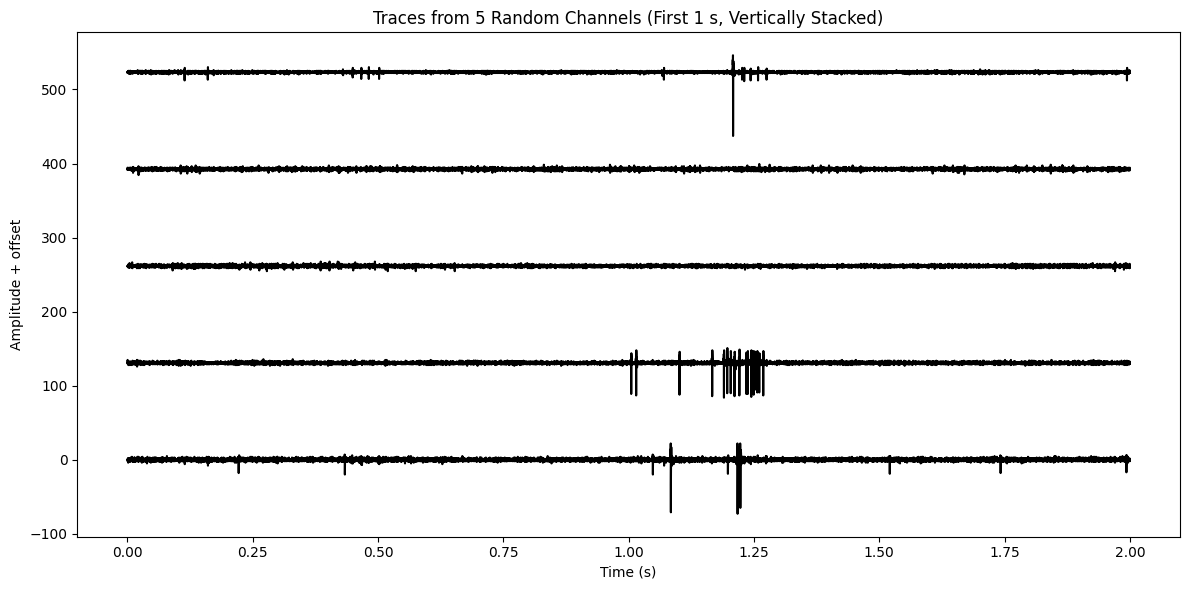

In [12]:
# Plot 5 random channels with vertical spacing between traces
import matplotlib.pyplot as plt
import numpy as np
sampling_rate = rec_bin.get_sampling_frequency()
traces = rec_bin.get_traces(segment_index=0)  # shape: (samples, channels)
n_samples = 20000  # first 1 s at 10 kHz
time_vector = np.arange(n_samples) / sampling_rate
np.random.seed(690)  # For reproducibility
channels_to_plot = np.random.choice(traces.shape[1], size=5, replace=False)

# Set vertical spacing from signal scale
trace_block = traces[:n_samples, channels_to_plot]
vertical_spacing = 1.2 * np.ptp(trace_block)

plt.figure(figsize=(12, 6))
for i, ch in enumerate(channels_to_plot):
    y_offset = i * vertical_spacing
    plt.plot(time_vector, traces[:n_samples, ch] + y_offset, label=f'Channel {ch}',color='black')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude + offset')
plt.title('Traces from 5 Random Channels (First 1 s, Vertically Stacked)')
#plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.savefig('./Traces_5_random_channels.svg', dpi=300)
plt.show()